In [1]:
import pandas as pd
import numpy as np

In [3]:
# Ajusta la ruta al archivo descargado
columns = [
    "ID", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
    "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei",
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

df = pd.read_csv("./dataset/breast-cancer-wisconsin.data", header=None, names=columns)
df.head()

,ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [4]:
# Información general
df.info()

# Estadísticas descriptivas
df.describe()

# Conteo de valores faltantes
df.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           699 non-null    int64
 1   Clump_Thickness              699 non-null    int64
 2   Uniformity_Cell_Size         699 non-null    int64
 3   Uniformity_Cell_Shape        699 non-null    int64
 4   Marginal_Adhesion            699 non-null    int64
 5   Single_Epithelial_Cell_Size  699 non-null    int64
 6   Bare_Nuclei                  699 non-null    str  
 7   Bland_Chromatin              699 non-null    int64
 8   Normal_Nucleoli              699 non-null    int64
 9   Mitoses                      699 non-null    int64
 10  Class                        699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB


ID                             0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

In [5]:
# Reemplazar "?" por NaN
df = df.replace("?", np.nan)

# Revisar nuevamente faltantes
df.isna().sum()

ID                              0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [6]:
# Convertir columnas numéricas a tipo numérico
numeric_cols = df.columns.drop(["ID","Class"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Revisar tipos
df.dtypes

ID                               int64
Clump_Thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object

In [7]:
# Imputar con la mediana en columnas numéricas
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


In [8]:
# Class: 2 = benigno, 4 = maligno
df["Class"] = df["Class"].map({2:0, 4:1})

df["Class"].value_counts()

Class
0    458
1    241
Name: count, dtype: int64

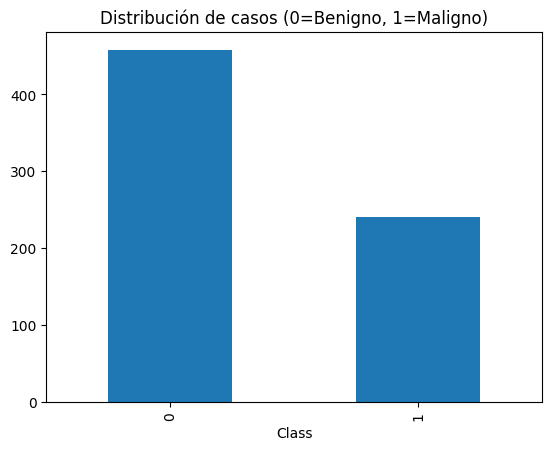

In [9]:
import matplotlib.pyplot as plt

# Distribución de la variable target
df["Class"].value_counts().plot(kind="bar")
plt.title("Distribución de casos (0=Benigno, 1=Maligno)")
plt.show()


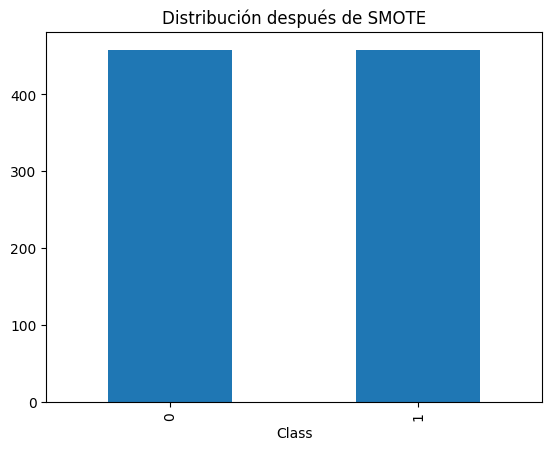

In [10]:
#Aplicar sobremuestreo con SMOTE
from imblearn.over_sampling import SMOTE
X = df.drop(columns=["ID", "Class"])
y = df["Class"]
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
# Verificar nueva distribución
pd.Series(y_resampled).value_counts().plot(kind="bar")
plt.title("Distribución después de SMOTE")
plt.show()